<a href="https://colab.research.google.com/github/kaoru1018/Where-Do-They-Go-Analyzing-Thailand-Tourism-Data-2019-2023-/blob/main/Where_Do_They_Go%3F_Analyzing_Thailand_Tourism_Data_(2019_2023).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓ 読み込み成功: 30,800 行 × 7 項目（タイの観光データ）
📖 読み込んだファイル: thailand_domestic_tourism_2019_2023_ver2.csv
--- データの先頭5行 ---


,date,province_thai,province_eng,region_thai,region_eng,variable,value
0,2019-01-01,กรุงเทพมหานคร,Bangkok,ภาคกลาง,central,ratio_tourist_stay,93.37
1,2019-01-01,ลพบุรี,Lopburi,ภาคกลาง,central,ratio_tourist_stay,61.32
2,2019-01-01,พระนครศรีอยุธยา,Phra Nakhon Si Ayutthaya,ภาคกลาง,central,ratio_tourist_stay,73.37
3,2019-01-01,สระบุรี,Saraburi,ภาคกลาง,central,ratio_tourist_stay,67.33
4,2019-01-01,ชัยนาท,Chainat,ภาคกลาง,central,ratio_tourist_stay,79.31


--- データに含まれる項目の一覧 ---
['ratio_tourist_stay' 'no_tourist_stay' 'no_tourist_all' 'no_tourist_thai'
 'no_tourist_foreign' 'revenue_all' 'revenue_thai' 'revenue_foreign']
👑 【タイ人国内旅行】 に大人気の県 TOP10
province_eng
Bangkok                      106899866.0
Kanchanaburi                  33180427.0
Chonburi                      32260927.0
Phetchaburi                   27306554.0
Nakhon Ratchasima             26118369.0
Chiang Mai                    25858062.0
Prachuap Khiri Khan           24206578.0
Phra Nakhon Si Ayutthaya      20861804.0
Rayong                        15035941.0
Khon Kaen                     13901696.0
Name: value, dtype: float64

---------------------------------------------

👑 【外国人観光客】 に大人気の県 TOP10
province_eng
Bangkok                      44452634.0
Phuket                       17525594.0
Chonburi                     14660424.0
Chiang Mai                    5904641.0
Krabi                         5457707.0
Surat Thani                   5424521.0
Songkhla                      48

/tmp/ipykernel_5841/1972173592.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_5841/1972173592.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


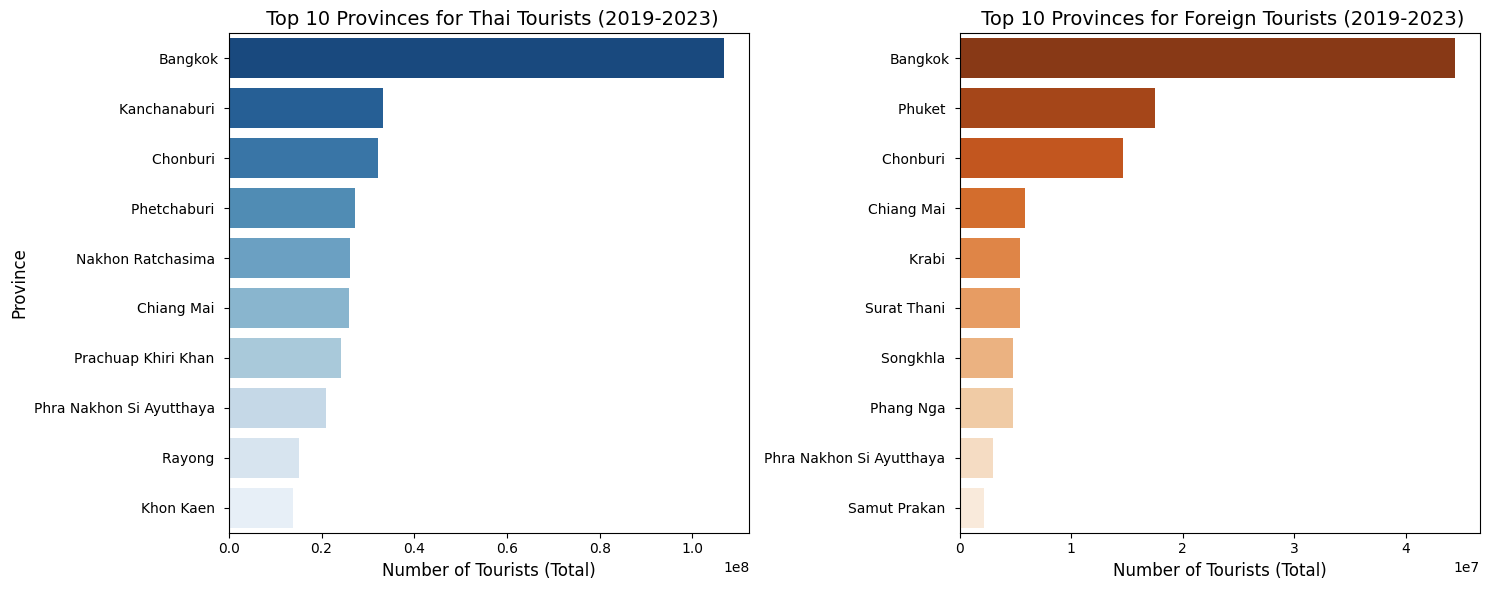

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os


# まずKaggleのフォルダの中を探します
csv_files = glob.glob("/kaggle/input/**/*.csv", recursive=True)

#  どこで動いているかに応じて、読み込むファイルの住所を自動で切り替えます
if csv_files:
    # 【Kaggleの場合】見つかったファイルを自動指定
    target_path = csv_files[0]
else:
    # 【Colabの場合】あなたがアップロードした直下のファイルを指定
    target_path = "thailand_domestic_tourism_2019_2023_ver2.csv"

#  実際にデータを読み込みます
try:
    if os.path.exists(target_path):
        df = pd.read_csv(target_path)
        print(f"✓ 読み込み成功: {df.shape[0]:,} 行 × {df.shape[1]} 項目（タイの観光データ）")
        print(f"📖 読み込んだファイル: {os.path.basename(target_path)}")
    else:
        print(
           f"❌ CSVファイルが見つかりません。ファイル名が '{target_path}' になっているか、アップロード先を確認してください。"
        )
        df = pd.DataFrame()
except Exception as e:
    print(f"❌ エラーが発生しました: {e}")
    df = pd.DataFrame()

    #  最初の5行を表示して、データの雰囲気を掴む
print("--- データの先頭5行 ---")
display(df.head())

# variableの列に、どんな種類の言葉（項目）が入っているかをすべて表示します
print("--- データに含まれる項目の一覧 ---")
print(df["variable"].unique())

# 1. タイ人観光客数（no_tourist_thai）だけを絞り込んで、県ごとに合計して、多い順に並べる
thai_ranking = (
    df[df["variable"] == "no_tourist_thai"]
    .groupby("province_eng")["value"]
    .sum()
    .sort_values(ascending=False)
)

# 2. 外国人観光客数（no_tourist_foreign）だけを絞り込んで、県ごとに合計して、多い順に並べる
foreign_ranking = (
    df[df["variable"] == "no_tourist_foreign"]
    .groupby("province_eng")["value"]
    .sum()
    .sort_values(ascending=False)
)

# 3. 両方のトップ10を並べて表示する
print("👑 【タイ人国内旅行】 に大人気の県 TOP10")
print(thai_ranking.head(10))
print("\n---------------------------------------------\n")
print("👑 【外国人観光客】 に大人気の県 TOP10")
print(foreign_ranking.head(10))

# グラフの全体のサイズを設定します（横幅15インチ、高さ6インチ）
plt.figure(figsize=(15, 6))

# --- 左側のグラフ：タイ人国内旅行 TOP10 ---
plt.subplot(1, 2, 1)  # 1行2列の画面を作って、その1番目（左）に描くという意味です
sns.barplot(
    x=thai_ranking.head(10).values,
    y=thai_ranking.head(10).index,
    palette="Blues_r",  # 青系のグラデーション（上ほど濃い）
)
plt.title(" Top 10 Provinces for Thai Tourists (2019-2023)", fontsize=14)
plt.xlabel("Number of Tourists (Total)", fontsize=12)
plt.ylabel("Province", fontsize=12)

# --- 右側のグラフ：外国人観光客 TOP10 ---
plt.subplot(1, 2, 2)  # 1行2列の2番目（右）に描くという意味です
sns.barplot(
    x=foreign_ranking.head(10).values,
    y=foreign_ranking.head(10).index,
    palette="Oranges_r",  # オレンジ系のグラデーション（上ほど濃い）
)
plt.title(" Top 10 Provinces for Foreign Tourists (2019-2023)", fontsize=14)
plt.xlabel("Number of Tourists (Total)", fontsize=12)
plt.ylabel("")  # 右側は県名が重複するので、見た目をスッキリさせるために省略します

# 左右のグラフが被らないように、自動で綺麗な隙間に調整します
plt.tight_layout()

# 画面にグラフをドンと表示します！
plt.show()

